<a href="https://colab.research.google.com/github/juannMGC/Trabajo-de-Grado/blob/main/PropuestaTGRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

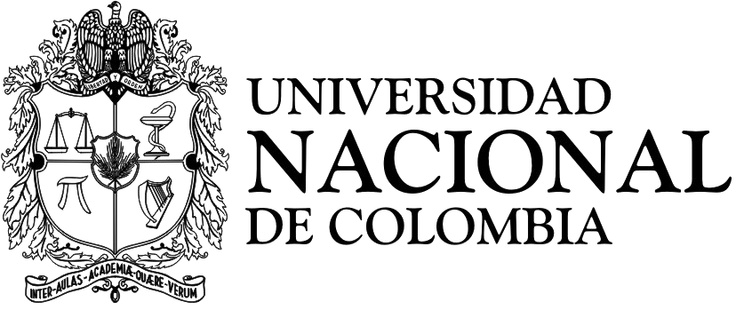
# **Proyecto Final: Machine Learning para predecir el impacto de la calidad del aire en la salud en Manizales.**

**Descripcion**

**Audiencia**

**Preguntas/Problema que buscamos resolver**

**Autor:** Juan Manuel Garcia Cifuentes

**Correo:** jugarciaci@unal.edu.co

# 0. Importación de datos y librerias

In [1]:
# MANIPULACIÓN DE DATOS
import pandas as pd
import numpy as np

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESAMIENTO
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, KFold

# MODELOS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# MÉTRICAS
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score,roc_curve,auc
)

# BALANCEO
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# GUARDADO
import joblib


# 1. CARGA Y LIMPIEZA PROFUNDA

In [2]:
df = pd.read_excel('BD_impacto_salud.xlsx')
df.replace(['-200', -200, -200.0, '-200.0', '', ' '], np.nan, inplace=True)

for feature in df.columns:
    df[feature] = df[feature].astype(str).str.replace(',', '.')
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

In [3]:
sns.set_palette("pastel")
sns.set_style("whitegrid")

plt.style.use('ggplot')
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# 2. Análisis Exploratorio de Datos (EDA)

Las variables del conjunto son las siguientes:


*   ICA (Índice de Calidad del Aire): Variable numérica que resume el nivel de contaminación general. (Rango: 0 a 5).
*   PM_10: Concentración de partículas sólidas o líquidas de polvo, cenizas, hollín, metálicas, cemento o polen, dispersas en la atmósfera, cuyo diámetro es menor a $10 \mu m$.
*   PM2_5: Partículas finas con un diámetro de $2.5 \mu m$ o menos. Son las más peligrosas para la salud ya que penetran profundamente en los pulmones.
*   SO2 (Dióxido de Azufre): Gas incoloro con olor irritante que se origina sobre todo en la combustión de carburantes fósiles que contienen azufre.
*   O3 (Ozono): Gas que se encuentra en las capas altas de la atmósfera y en niveles bajos puede ser un contaminante irritante.
*   Temperatura: Temperatura ambiental registrada en el momento de la medición.
*   Humedad: Porcentaje de humedad relativa en el aire.
*   VelocidadViento: Velocidad del viento, factor clave en la dispersión de contaminantes.
*   IngresosHospitalariosR / C: Número de ingresos de pacientes al hospital por causas Respiratorias (R) o Cardiovasculares (C).
*   ConsultaHospitalariosR / C: Número de consultas ambulatorias o de urgencias por causas Respiratorias (R) o Cardiovasculares (C).







# 2. IMPUTACIÓN (Mediana para evitar sesgos por ruido)

In [4]:
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

def aqi_bin(x):
    x = round(x)
    if x == 0: return 'Buenas'
    elif x == 1: return 'Moderada'
    elif x == 2: return 'Dañina (Grupos Sensitivos)'
    elif x == 3: return 'Dañina a la Salud'
    elif x == 4: return 'Muy Dañina'
    else: return 'Arriesgado'

df_imputed['AQI_Category'] = df_imputed['ICA'].apply(aqi_bin)

In [5]:
print("Filas, columnas: ", df.shape)
print("\nNombres de las variables: \n", df.columns)
print("\nTipos de datos: \n", df.dtypes)
print("\nValores faltantes: \n", df.isnull().sum())
print("\nEstadísticas descriptivas: \n", df.describe(include=[np.number]))

for col in df.select_dtypes(include=['object']).columns:
    print("\nFrecuencia de valores únicos de", col)
    print(df[col].value_counts())

Filas, columnas:  (1384, 12)

Nombres de las variables: 
 Index(['ICA', 'PM_10', 'PM2_5', 'SO2', 'O3', 'Temperatura', 'Humedad',
       'VelocidadViento', 'IngresosHospitalariosR', 'ConsultaHospitalariosR',
       'IngresosHospitalariosC', 'ConsultaHospitalariosC'],
      dtype='object')

Tipos de datos: 
 ICA                         int64
PM_10                     float64
PM2_5                       int64
SO2                         int64
O3                          int64
Temperatura               float64
Humedad                   float64
VelocidadViento           float64
IngresosHospitalariosR      int64
ConsultaHospitalariosR      int64
IngresosHospitalariosC      int64
ConsultaHospitalariosC      int64
dtype: object

Valores faltantes: 
 ICA                       0
PM_10                     0
PM2_5                     0
SO2                       0
O3                        0
Temperatura               0
Humedad                   1
VelocidadViento           0
IngresosHospitalariosR  

# 3.2 Análisis de valores atípicos

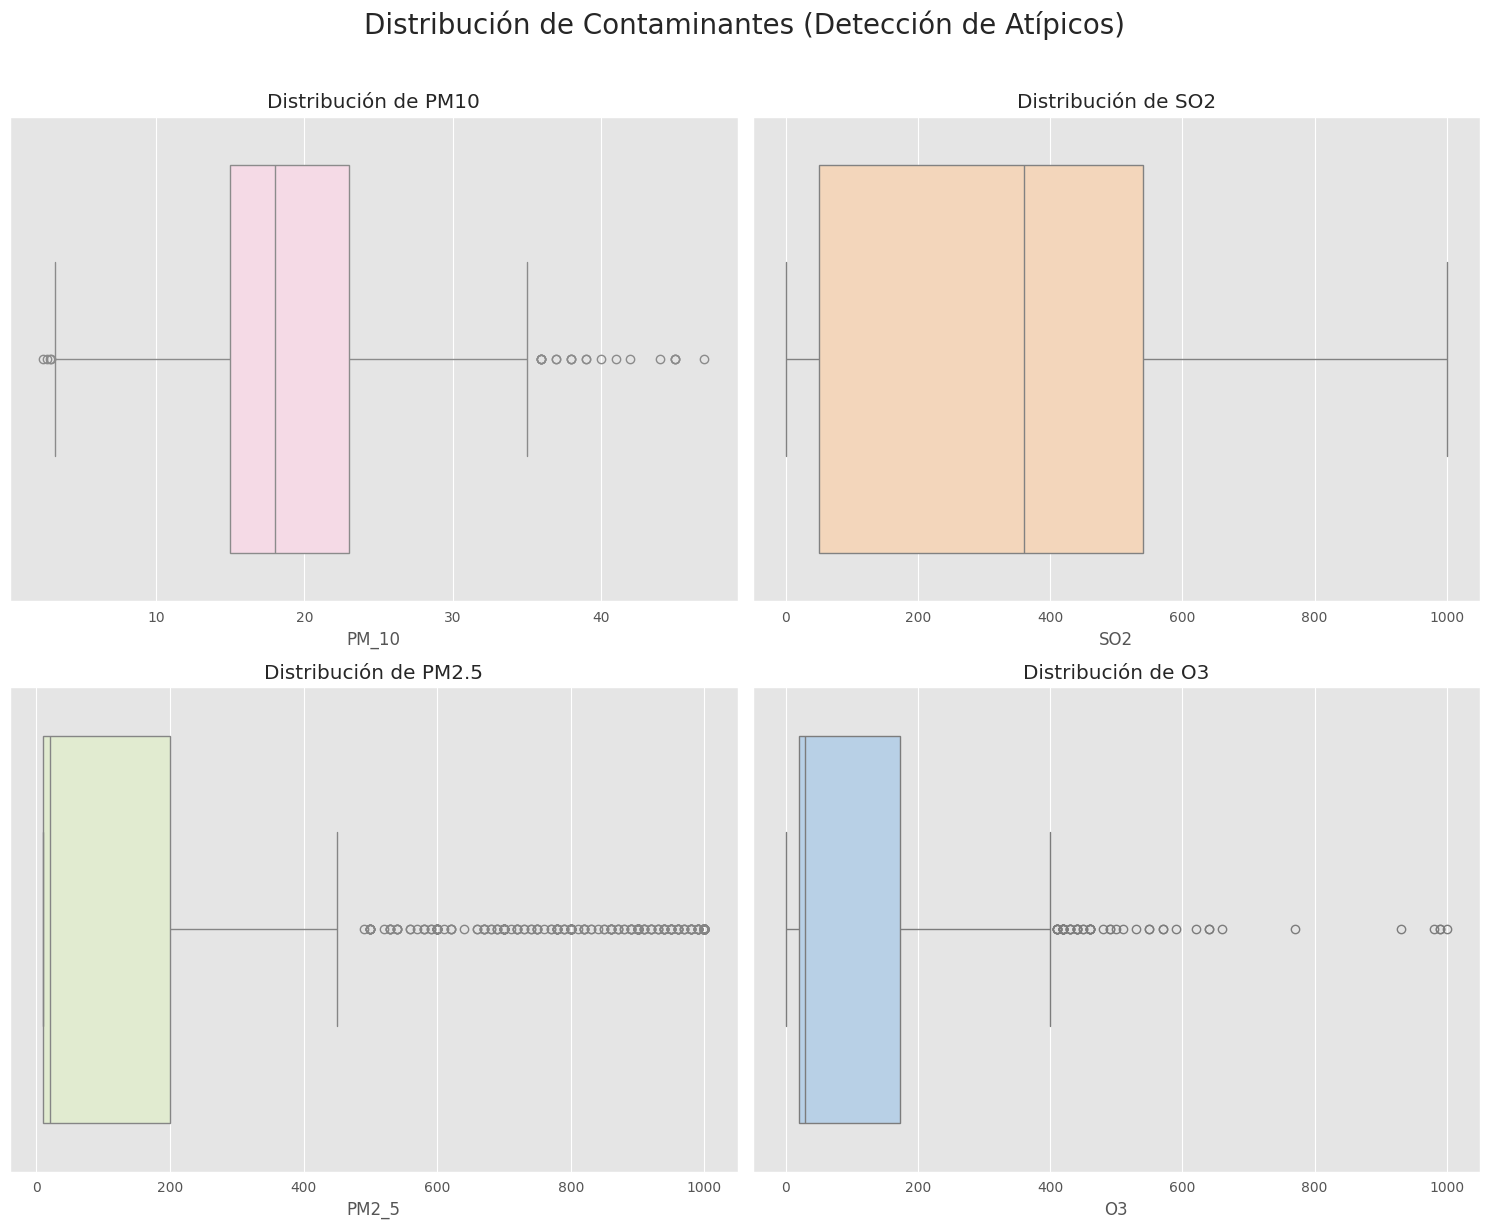

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle('Distribución de Contaminantes (Detección de Atípicos)', fontsize=20, y=1.02)

sns.boxplot(x=df_imputed['PM_10'], ax=axs[0, 0], color='#F9D5E5')
sns.boxplot(x=df_imputed['SO2'], ax=axs[0, 1], color='#FDD5B1')
sns.boxplot(x=df_imputed['PM2_5'], ax=axs[1, 0], color='#E2F0CB')
sns.boxplot(x=df_imputed['O3'], ax=axs[1, 1], color='#B1D1ED')

axs[0, 0].set_title('Distribución de PM10')
axs[0, 1].set_title('Distribución de SO2')
axs[1, 0].set_title('Distribución de PM2.5')
axs[1, 1].set_title('Distribución de O3')

plt.tight_layout()
plt.show()

# 3.5 Distribución de variables numéricas

Media de PM_10: 19.140213209364163
Media de PM2_5: 215.70809248554914
Media de SO2: 332.78179190751445
Media de O3: 104.21965317919076


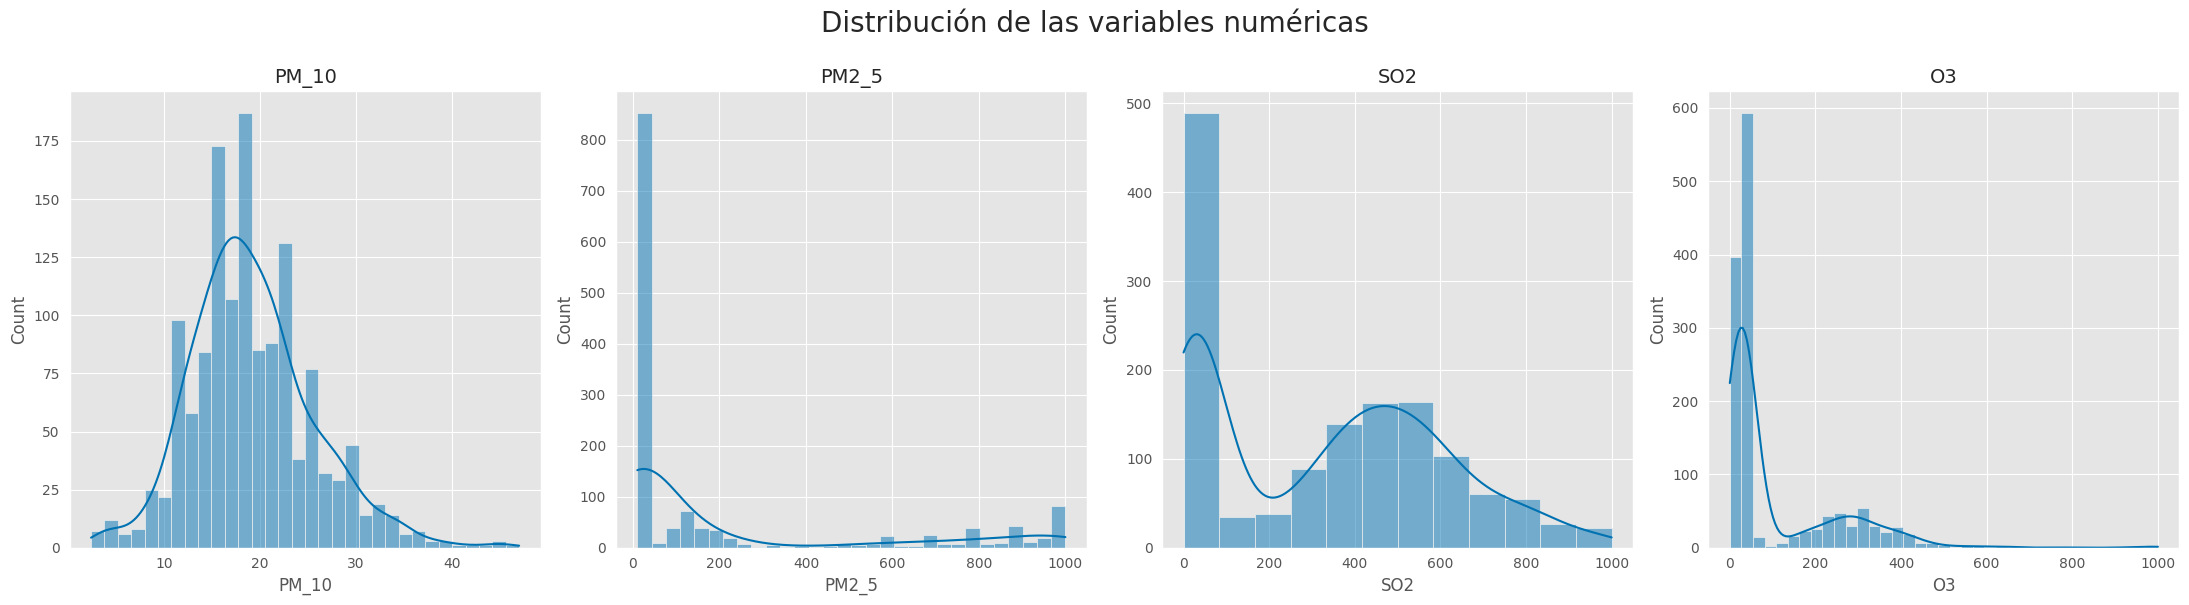

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 6))
fig.suptitle('Distribución de las variables numéricas', fontsize=20, y=1.0)

num_cols = ['PM_10', 'PM2_5', 'SO2', 'O3']

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=df, ax=axs[i], kde=True, color='#0072B2')
    axs[i].set_title(col, fontsize=14)
    print(f'Media de {col}: {df[col].mean()}')

plt.tight_layout()
plt.show()

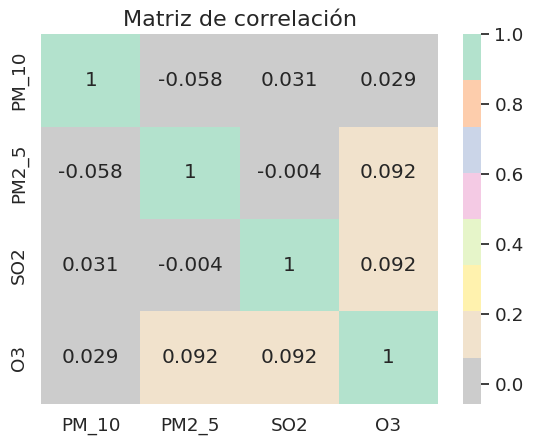

In [8]:
# Correlación entre variables numéricas
corr_matrix = df[num_cols].corr()

sns.set(font_scale=1.2)
sns.heatmap(corr_matrix, annot=True, cmap='Pastel2_r')
plt.title('Matriz de correlación', fontsize=16)
plt.show()

# 3.6 Relación entre las variables numericas y la tasa de alertas de salud

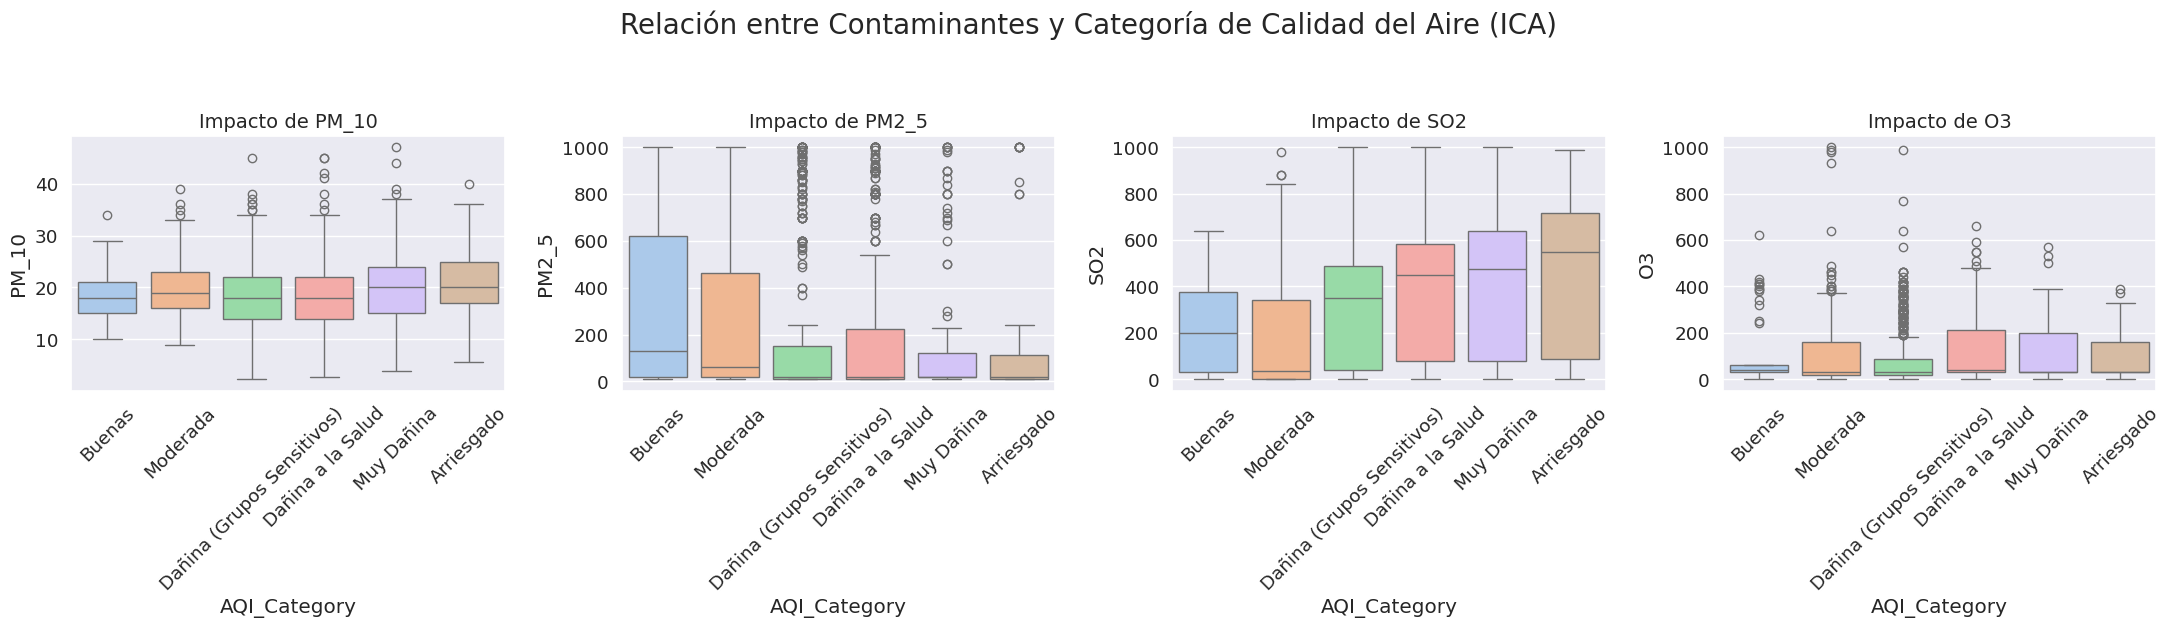

In [9]:
num_cols = ['PM_10', 'PM2_5', 'SO2', 'O3']
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 6))
fig.suptitle('Relación entre Contaminantes y Categoría de Calidad del Aire (ICA)', fontsize=20, y=1.05)

for i, col in enumerate(num_cols):
    sns.boxplot(x='AQI_Category', y=col, data=df_imputed, ax=axs[i], palette='pastel', hue='AQI_Category', legend=False)

    axs[i].set_title(f'Impacto de {col}', fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3.8 Análisis específicos para responder a las preguntas de investigación



Pregunta: ¿Cuál es el contaminante que más impacta en los ingresos hospitalarios respiratorios?

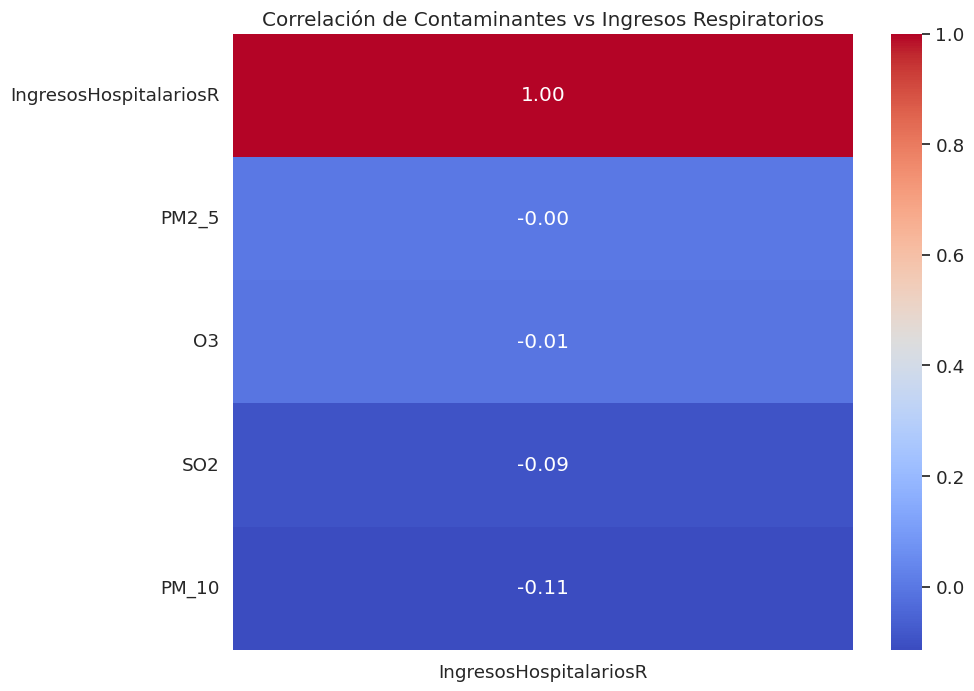

El contaminante con mayor impacto potencial es: PM2_5


In [10]:
# Análisis de correlación específico
impacto_salud = df_imputed[['PM_10', 'PM2_5', 'SO2', 'O3', 'IngresosHospitalariosR']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(impacto_salud[['IngresosHospitalariosR']].sort_values(by='IngresosHospitalariosR', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Contaminantes vs Ingresos Respiratorios')
plt.show()

# Identificación automática
max_corr = impacto_salud['IngresosHospitalariosR'].drop('IngresosHospitalariosR').idxmax()
print(f"El contaminante con mayor impacto potencial es: {max_corr}")

Pregunta: ¿Existe una relación entre la Velocidad del Viento y la dispersión de PM2.5?

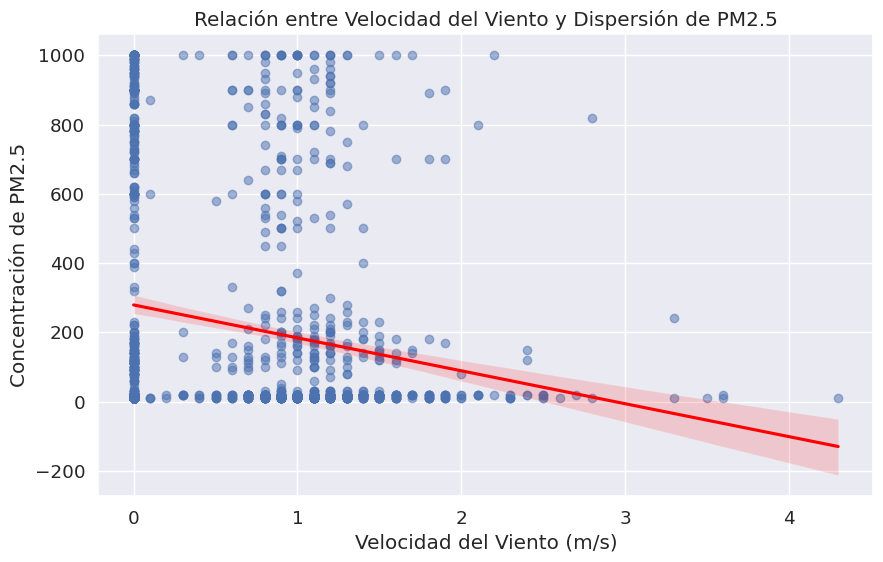

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='VelocidadViento', y='PM2_5', data=df_imputed,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación entre Velocidad del Viento y Dispersión de PM2.5')
plt.xlabel('Velocidad del Viento (m/s)')
plt.ylabel('Concentración de PM2.5')
plt.show()

Pregunta: ¿Cómo varían las consultas médicas según la clasificación del ICA?

/tmp/ipython-input-1169217057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AQI_Category', y='ConsultaHospitalariosR', data=df_imputed,


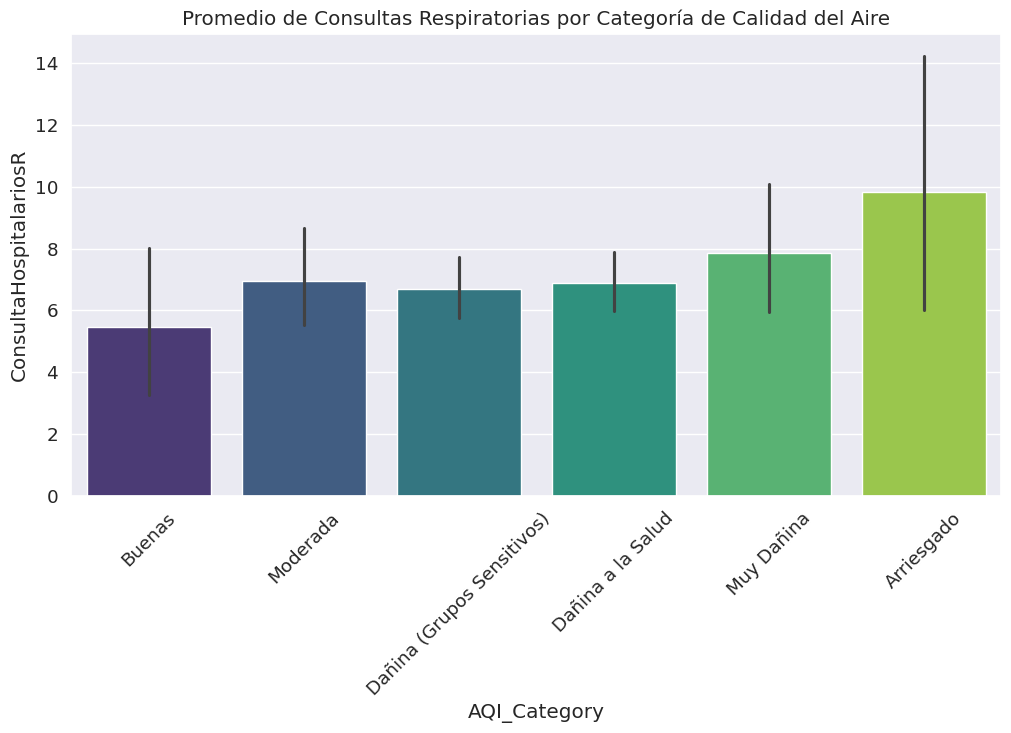

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x='AQI_Category', y='ConsultaHospitalariosR', data=df_imputed,
            order=['Buenas', 'Moderada', 'Dañina (Grupos Sensitivos)', 'Dañina a la Salud', 'Muy Dañina', 'Arriesgado'],
            palette='viridis')
plt.title('Promedio de Consultas Respiratorias por Categoría de Calidad del Aire')
plt.xticks(rotation=45)
plt.show()

# 3.9 Informe sobre análisis




# 4. Ingeniería de atributos

Con el análisis exploratorio de datos se identificaron las variables mas importantes para la predicción de la tasa:


*   Separacion y codificacion
*   Balanceo con smote



In [13]:
X = df_imputed.drop(columns=['AQI_Category', 'ICA'])
y = df_imputed['AQI_Category']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [14]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_encoded)

# 5. Entrenamiento y Testeo

5.1 División de datos

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=42
)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5.2 Entrenamiento y evaluación de modelos:

Los modelos elegidos fueron Knn, Redes neuornales, Random Forest, Xgboost.

In [17]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print(f"Precisión KNN: {accuracy_score(y_test, y_pred_knn):.4f}")
knn_probs = knn.predict_proba(X_test_scaled)
print("ROC AUC KNN:", roc_auc_score(y_test, knn_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

Precisión KNN: 0.5992
ROC AUC KNN: 0.8376333857079609
                            precision    recall  f1-score   support

                Arriesgado       0.64      0.95      0.77        86
                    Buenas       0.71      0.95      0.82        86
Dañina (Grupos Sensitivos)       0.46      0.38      0.42        87
         Dañina a la Salud       0.29      0.16      0.21        87
                  Moderada       0.58      0.49      0.53        87
                Muy Dañina       0.69      0.66      0.67        86

                  accuracy                           0.60       519
                 macro avg       0.56      0.60      0.57       519
              weighted avg       0.56      0.60      0.57       519



In [18]:
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
print(f"Precisión Redes Neuronales: {accuracy_score(y_test, y_pred_mlp):.4f}")
mlp_probs = mlp.predict_proba(X_test_scaled)
print("ROC AUC Redes Neuronales:", roc_auc_score(y_test, mlp_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

Precisión Redes Neuronales: 0.6243
ROC AUC Redes Neuronales: 0.8488068041180205
                            precision    recall  f1-score   support

                Arriesgado       0.88      0.88      0.88        86
                    Buenas       0.92      0.90      0.91        86
Dañina (Grupos Sensitivos)       0.37      0.33      0.35        87
         Dañina a la Salud       0.35      0.25      0.30        87
                  Moderada       0.53      0.57      0.55        87
                Muy Dañina       0.61      0.81      0.70        86

                  accuracy                           0.62       519
                 macro avg       0.61      0.63      0.61       519
              weighted avg       0.61      0.62      0.61       519



In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(f"Precisión Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
rf_probs = rf.predict_proba(X_test_scaled)
print("ROC AUC Random Forest:", roc_auc_score(y_test, rf_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Precisión Random Forest: 0.6994
ROC AUC Random Forest: 0.9194363630307851
                            precision    recall  f1-score   support

                Arriesgado       0.92      0.92      0.92        86
                    Buenas       0.90      0.95      0.93        86
Dañina (Grupos Sensitivos)       0.45      0.46      0.46        87
         Dañina a la Salud       0.50      0.51      0.50        87
                  Moderada       0.75      0.67      0.71        87
                Muy Dañina       0.67      0.70      0.69        86

                  accuracy                           0.70       519
                 macro avg       0.70      0.70      0.70       519
              weighted avg       0.70      0.70      0.70       519



In [20]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print(f"Precisión XGBoost: {accuracy_score(y_test, y_pred_xgb):.4f}")
xgb_probs = xgb.predict_proba(X_test_scaled)
print("ROC AUC XGBoost:", roc_auc_score(y_test, xgb_probs, multi_class='ovr'))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Precisión XGBoost: 0.7033
ROC AUC XGBoost: 0.922550963329297
                            precision    recall  f1-score   support

                Arriesgado       0.91      0.90      0.90        86
                    Buenas       0.90      0.92      0.91        86
Dañina (Grupos Sensitivos)       0.46      0.52      0.49        87
         Dañina a la Salud       0.49      0.49      0.49        87
                  Moderada       0.74      0.69      0.71        87
                Muy Dañina       0.75      0.71      0.73        86

                  accuracy                           0.70       519
                 macro avg       0.71      0.70      0.71       519
              weighted avg       0.71      0.70      0.71       519



  # 4.1. VALIDACION CRUZADA

In [21]:
num_folds = 5

kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

models = [
    ('Knn', KNeighborsClassifier()),
    ('Redes Neuronales', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42)),
]

results = []
names = []
print('Metricas \n----------------------\n')
for name, model in models:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {round(cv_results.mean(), 5)} ({round(cv_results.std(), 5)})')


Metricas 
----------------------

Knn: 0.51569 (0.01552)
Redes Neuronales: 0.59289 (0.02572)
Random Forest: 0.6493 (0.0127)
XGBoost: 0.6406 (0.01999)


# 5.OPTIMIZACION Y SELECCION DE  MODELO

In [22]:
param_grids = {
    "Knn": {
        'modelo__n_neighbors': [1, 2, 3],
        'modelo__weights': ['distance', 'uniform'],
        'modelo__metric': ['manhattan', 'euclidean']
    },
    "Redes Neuronales": {
        'modelo__hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'modelo__activation': ['relu', 'logistic'],
        'modelo__alpha': [0.0001, 0.01]
    },
    "Random Forest": {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [None, 20],
        'modelo__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [10, 15],
        'modelo__learning_rate': [0.05, 0.1]
    }
}

result = []
best_models = {}

print('--------------------------------------------')

for name, model in models:
    pipe = Pipeline([('modelo', model)])
    grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    best_models[name] = grid.best_estimator_
    best_score = grid.best_score_
    test_score = grid.score(X_test_scaled, y_test)

    result.append({
        'Modelo': name,
        'Score_Train': round(best_score, 5),
        'Score_Test': round(test_score, 5),
        'Mejores_Params': grid.best_params_
    })

    print(f"{name}")
    print(f"   - Precisión CV: {best_score:.5f}")
    print(f"   - Precisión Test: {test_score:.5f}")
    print('--------------------------------------------')

result = sorted(result, key=lambda k: k['Score_Test'], reverse=True)
for res in result:
    print(f"{res['Modelo']}: Train({res['Score_Train']}) | Test({res['Score_Test']})")

--------------------------------------------
Knn
   - Precisión CV: 0.62567
   - Precisión Test: 0.65511
--------------------------------------------
Redes Neuronales
   - Precisión CV: 0.60493
   - Precisión Test: 0.62235
--------------------------------------------
Random Forest
   - Precisión CV: 0.64496
   - Precisión Test: 0.70328
--------------------------------------------
XGBoost
   - Precisión CV: 0.65460
   - Precisión Test: 0.69942
--------------------------------------------
Random Forest: Train(0.64496) | Test(0.70328)
XGBoost: Train(0.6546) | Test(0.69942)
Knn: Train(0.62567) | Test(0.65511)
Redes Neuronales: Train(0.60493) | Test(0.62235)


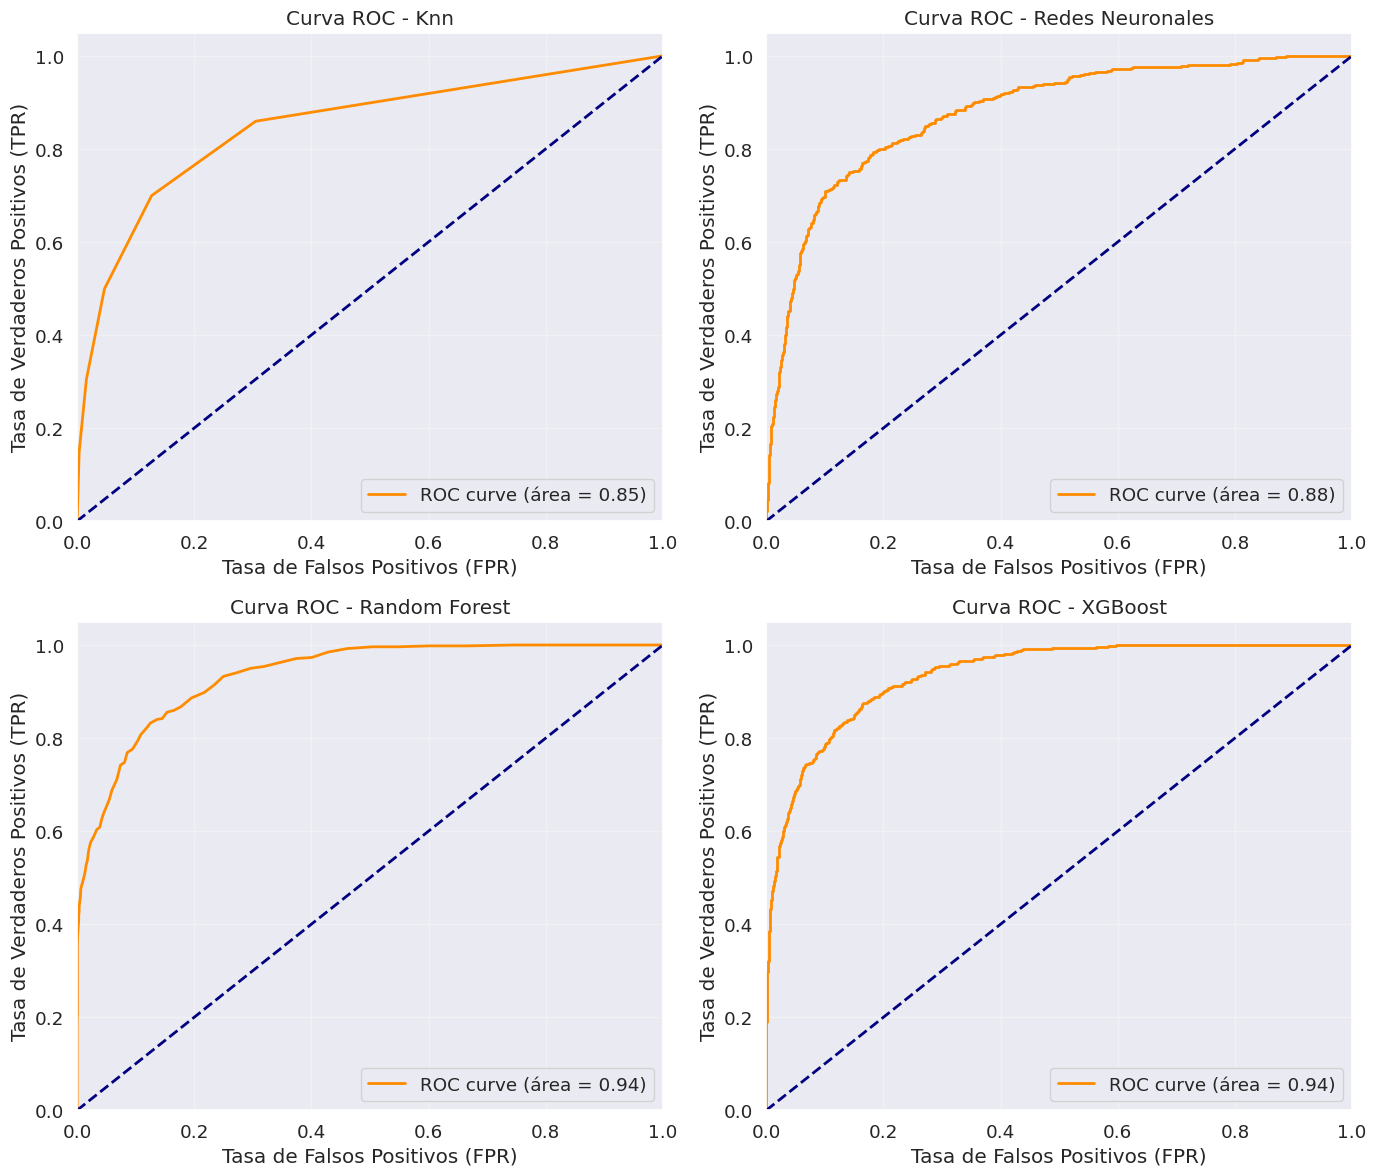

In [23]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
n_classes = y_test_bin.shape[1]

modelos_entrenados = [
    ('Knn', knn),
    ('Redes Neuronales', mlp),
    ('Random Forest', rf),
    ('XGBoost', xgb)
]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axs = axs.flatten()

for i, (name, model) in enumerate(modelos_entrenados):
    y_score = model.predict_proba(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    axs[i].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (área = {roc_auc:.2f})')
    axs[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    axs[i].set_xlim([0.0, 1.0])
    axs[i].set_ylim([0.0, 1.05])
    axs[i].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axs[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axs[i].set_title(f'Curva ROC - {name}')
    axs[i].legend(loc="lower right")
    axs[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6.IMPORTACION DEL MEJOR MODELO DE PREDICCION PARA VISUALIZACION

In [24]:
# Guardar el ganador absoluto para la App
mejor_modelo_final = best_models[result[0]['Modelo']]
joblib.dump(mejor_modelo_final, 'mejor_modelo.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(X.columns, 'features.pkl')


['features.pkl']

#7. VISUALIZACION EN STREAMLIT

In [25]:
!pip install streamlit
!pip install streamlit-lottie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.2 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 10.2 MB/s eta 0:00:00


In [35]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import requests
from streamlit_lottie import st_lottie

# 1. Configuración de la Página y Estilo Visual
st.set_page_config(
    page_title="Investigación Aire Manizales",
    layout="wide",
    page_icon="🏔️"
)

# Función para cargar animaciones Lottie
def cargar_lottie_url(url):
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

lottie_salud = cargar_lottie_url("https://lottie.host/3d5ee517-de54-4bf5-a42f-8c87c929dc5c/Bk2pUIGElP.json")
lottie_salud1 = cargar_lottie_url("https://lottie.host/95af0ede-15a3-4890-a1dd-1063b49e88cb/Vik32cUg12.json")

# Estilos personalizados para mejorar la presentación de la tesis
st.markdown("""
    <style>
    .main { background-color: #f8f9fa; }
    .stMetric { background-color: white; padding: 20px; border-radius: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); }
    div[data-testid="stExpander"] { background-color: white; border-radius: 10px; }
    </style>
    """, unsafe_allow_html=True)

# 2. Carga Segura de Activos del Modelo
@st.cache_resource
def load_assets():
    try:
        # Cargamos los archivos generados en el punto 6 del notebook
        model = joblib.load('mejor_modelo.pkl')
        scaler = joblib.load('scaler.pkl')
        le = joblib.load('label_encoder.pkl')
        features = joblib.load('features.pkl')
        return model, scaler, le, features, None
    except Exception as e:
        return None, None, None, None, str(e)

model, scaler, le, features, error = load_assets()

# Validación de carga
if error:
    st.error(f"⚠️ Error Crítico de Carga: {error}")
    st.info("Asegúrate de que los archivos 'mejor_modelo.pkl', 'scaler.pkl', 'label_encoder.pkl' y 'features.pkl' estén en la misma carpeta.")
    st.stop()

with st.sidebar:
    st.title("🔮 Proyecto de Investigación: Calidad del Aire en Manizales")
    st_lottie(lottie_salud, speed=1, height=150, key="salud")
    st.sidebar.write("Ajuste los niveles actuales detectados para predecir el impacto en salud pública.")

def get_user_inputs():
    input_dict = {}
    for col in features:
        if 'Humedad' in col:
            input_dict[col] = st.sidebar.slider(f"{col} (%)", 0.0, 100.0, 75.0)
        elif 'Temperatura' in col:
            input_dict[col] = st.sidebar.slider(f"{col} (°C)", 0.0, 45.0, 18.0)
        elif 'Hospitalarios' in col or 'Consulta' in col:
            input_dict[col] = st.sidebar.number_input(f"{col}", min_value=0, value=1)
        else:
            # Contaminantes (PM10, PM2.5, SO2, O3)
            input_dict[col] = st.sidebar.slider(f"{col} (µg/m³)", 0.0, 500.0, 25.0)

    return pd.DataFrame([input_dict])[features]

df_input = get_user_inputs()

with st.sidebar:
  st_lottie(lottie_salud1, speed=1, height=150, key="salud1")

# 4. Cuerpo Principal
st.title("🩺 Proyecto de Investigación: Calidad del Aire en Manizales")
st.markdown("""
    **Metodología de Predicción:** Esta herramienta utiliza inteligencia artificial para evaluar el riesgo sanitario basándose en
    datos atmosféricos y registros de ingresos hospitalarios históricos de la ciudad.
""")

col_params, col_result = st.columns([1, 1])

with col_params:
    st.subheader("Parámetros de Simulación")
    # Mostrar tabla transpuesta para mejor lectura
    st.dataframe(df_input.T.rename(columns={0: 'Valor Actual'}), width='stretch')

with col_result:
    st.subheader("Clasificación del Impacto")

    # PROCESO DE PREDICCIÓN
    # A. Escalado
    try:
        input_scaled = scaler.transform(df_input)

        # B. Predicción de Clase
        pred_idx = model.predict(input_scaled)[0]
        label = le.inverse_transform([pred_idx])[0]

        # C. Probabilidades
        probs = model.predict_proba(input_scaled)
        confianza = np.max(probs) * 100

        # Mapeo de Colores Estándar ICA (Índice de Calidad del Aire)
        colors = {
            'Buenas': '#28a745',
            'Moderada': '#f1c40f',
            'Dañina (Grupos Sensitivos)': '#fd7e14',
            'Dañina a la Salud': '#dc3545',
            'Muy Dañina': '#6f42c1',
            'Arriesgado': '#343a40'
        }
        res_color = colors.get(label, '#007bff')

        # Tarjeta de Resultado Principal
        st.markdown(f"""
            <div style="background-color:{res_color}; padding:45px; border-radius:20px; text-align:center; color:white; border: 3px solid rgba(255,255,255,0.2);">
                <h1 style="margin:0; font-size:3.8em; font-weight:bold;">{label}</h1>
                <p style="margin:10px 0 0 0; font-size:1.6em; opacity:0.9;">Nivel de Confianza: {confianza:.2f}%</p>
            </div>
        """, unsafe_allow_html=True)

    except Exception as e:
        st.error(f"Error en la predicción: {e}")

# 5. Visualización de Probabilidades
st.write("---")
st.subheader("Análisis de Incertidumbre del Modelo")
st.write("Distribución de probabilidad para cada categoría de impacto:")

# Preparar datos para el gráfico de barras
prob_df = pd.DataFrame(probs, columns=le.classes_).T
prob_df.columns = ['Probabilidad (%)']
prob_df['Probabilidad (%)'] = prob_df['Probabilidad (%)'] * 100

st.bar_chart(prob_df, width='stretch')

# Pie de página académico
st.caption("Investigación sobre Machine Learning aplicado a la Salud Ambiental - Manizales, 2025.")

# Función para establecer la imagen de fondo con CSS
def set_background_image(url,opacity=0.5):
    st.markdown(
        f"""
        <style>
        .stApp {{
            background: url('{url}') no-repeat center center fixed;
            background-size: cover;
        }}
        </style>
        """,
        unsafe_allow_html=True
    )

#Llamar a la función para establecer el fondo de pantalla
set_background_image("https://i.morioh.com/52c215bc5f.png")

Overwriting app.py


In [36]:
# !pip install pyngrok

from pyngrok import ngrok
import os

# IMPORTANT: Replace "YOUR_VALID_NGROK_AUTHTOKEN" with your actual authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# This authtoken is necessary for ngrok to create a public tunnel.
ngrok.set_auth_token("2mtYHs82kdnyaMpvuUtSR7z3avo_3nc1wQKSHgUAg8cp7MhU7")

# Ejecutar Streamlit en segundo plano
os.system("streamlit run app.py &")

# Crear un túnel público con ngrok
# Streamlit runs on port 8501 by default
public_url = ngrok.connect(8501)
print(f"Tu aplicación está disponible en: {public_url}")

Tu aplicación está disponible en: NgrokTunnel: "https://c5a7-35-229-148-111.ngrok-free.app" -> "http://localhost:8501"
